<a href="https://colab.research.google.com/github/alejandraliebre08-lgtm/Analisis_Sentimientos_Shein/blob/main/An%C3%A1lisis_Sentimientos_Shein.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Proyecto Final - Data Science III**
## **Análisis de sentimientos en reseñas de compras de SHEIN**

**Autora:** **ALEJANDRA LORENA LIEBRE**

**Contexto:** se utiliza el dataset público **ShoppingAppReviews** (Kaggle, autora Jocelyn Dumlao), que contiene reseñas reales de usuarios sobre 12 apps de compras (Alibaba, AliExpress, Amazon, Daraz, eBay, Flipkart, Lazada, Meesho, Myntra, **Shein**, Snapdeal y Walmart). Se filtra el subconjunto correspondiente a **Shein** para el análisis. Cada reseña incluye texto y una calificación en estrellas, lo que permite construir etiquetas de sentimiento reales (no inferidas) a partir del puntaje que el propio usuario asignó.


### **ABSTRACT**

Este proyecto aborda la clasificación automática de sentimiento en reseñas de usuarios de la app de compras Shein, utilizando técnicas de Procesamiento de Lenguaje Natural (NLP) y Deep Learning. La **variable objetivo** es **sentimiento** (negativo / neutral / positivo), derivada de forma directa y verificable a partir del puntaje en estrellas que cada usuario asignó a su reseña. La **variable predictora (feature)** es el texto de la reseña, previamente limpiado y lematizado **content_lemma**.

Se entrenó una red neuronal y se la comparó con dos modelos clásicos de Machine Learning (Regresión Logística y Random Forest) usando vectorización TF-IDF. El hallazgo principal del trabajo es que los modelos clásicos superaron a la red neuronal en accuracy, un resultado atribuible principalmente al fuerte desbalance de clases.


In [150]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras

**1. ANÁLISIS EXPLORATORIO DE DATOS**

In [151]:
# CARGAR EL DATASET
url = 'https://docs.google.com/spreadsheets/d/e/2PACX-1vQgkOsLZPGsiPtpYq0XJlFwXOqSP1IlLFK7Te4ov0wfcfzZUnzsO1xtSXcQnPiEwoq8z5xsPHD7OWlP/pub?output=csv'
df = pd.read_csv(url)
df.head()


,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,9f73e569-bb36-4c35-a5c2-5412a3e32cc6,I have bought all my clothes from shein for th...,5,323,"1,72335E+12",NaN,NaN,Shein,NaN,NaN,NaN
1,731ca074-021f-40fa-a66e-bf7d55702450,PLEASE STOP IT WITH THE POP-UP OFFERS! You mak...,1,215,"1,72336E+12",Hi! Hope you have a nice shopping experience h...,"1,72328E+12",Shein,NaN,NaN,NaN
2,feab6570-16c8-4157-933c-1af2a55193ce,"Great app for shopping, but I love shein it's ...",2,160,"1,72291E+12",Hi! Hope you have a nice shopping experience h...,"1,72293E+12",Shein,NaN,NaN,NaN
3,32155d73-a4b5-4038-9ed5-9018c40acfb7,Update: one item out of 5 in order recently re...,3,20,"1,72317E+12",NaN,NaN,Shein,NaN,NaN,NaN
4,25316898-663a-4a52-ba0d-38b32335c499,"Nice app to buy hair accessories, summer dress...",4,7630,"1,71318E+12",NaN,NaN,Shein,NaN,NaN,NaN


**DESCRIPCION DE LAS VARIABLES**


**'ReviewId'**: Identificador único de cada reseña.                                                                         
**'Content'**: Texto de la reseña escrita por el usuario. Es la variable principal para el análisis NLP.                                      
**'Score'**: Calificación otorgada por el usuario, en una escala de 1 a 5 estrellas. Se utilizará para definir el sentimiento de la reseña.

**'ThumbsUpCount'**:  Cantidad de usuarios que marcaron la reseña como útil.                                                                         
**'At'**: Fecha y hora en que fue publicada la reseña, almacenada originalmente como timestamp.                                         
**'ReplyContent'**: Respuesta proporcionada por SHEIN a la reseña del usuario.                                                                    
**'RepliedAt'**: Fecha y hora en que SHEIN respondió a la reseña.                                                                      
**'AppName'**: Nombre de la aplicación a la que pertenece la reseña; en este análisis corresponde a SHEIN.                                   


In [152]:
# DIMENSIONES DEL DATASET
df.shape

(39951, 11)

In [153]:
# INFORMACIÓN GENERAL DEL DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39951 entries, 0 to 39950
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   reviewId       38412 non-null  object
 1   content        39861 non-null  object
 2   score          39685 non-null  object
 3   thumbsUpCount  38091 non-null  object
 4   at             37786 non-null  object
 5   replyContent   10264 non-null  object
 6   repliedAt      8764 non-null   object
 7   appName        36018 non-null  object
 8   Unnamed: 8     2 non-null      object
 9   Unnamed: 9     1 non-null      object
 10  Unnamed: 10    1 non-null      object
dtypes: object(11)
memory usage: 3.4+ MB


In [154]:
# ESTADISTICAS DESCRIPTIVAS DE LAS VARIABLES NÚMERICAS
df.describe()

,reviewId,content,score,thumbsUpCount,at,replyContent,repliedAt,appName,Unnamed: 8,Unnamed: 9,Unnamed: 10
count,38412,39861,39685,38091,37786,10264,8764,36018,2,1,1
unique,38041,38289,110,590,13203,1407,2849,3,2,1,1
top,It is our great honor to receive your praise,"your satisfaction is our eternal pursuit.""",5,0,"1,65094E+12",Hi! Hope you have a nice shopping experience h...,"1,66205E+12",Shein,Thailand. We will enlarge our cod service in ...,"1,57089E+12",Shein
freq,145,145,22575,21254,18,2595,32,36016,1,1,1


In [155]:
# DISTRIBUCIÓN DE PUNTUACIONES
df["score"].value_counts().sort_index()

,count
score,
"hope you enjoy shopping with SHEIN.""",1
"please be more patient about that. Many thanks.""",1
"please don't hesitate to contact us. Have a nice day!""",1
"we will consider your advice and will do our best to improve it as soon as possible.""",1
"we will consider your advice on our logistics and will do our best to improve it as soon as possible.""",1
...,...
69,1
Shein,1593
procrssing,1


In [156]:
# CANTIDAD DE VALORES NULOS POR COLUMNA
df.isnull().sum()

,0
reviewId,1539
content,90
score,266
thumbsUpCount,1860
at,2165
replyContent,29687
repliedAt,31187
appName,3933
Unnamed: 8,39949
Unnamed: 9,39950


In [157]:
df.duplicated().sum()

np.int64(1499)

Valores Duplicados: Se verificó la existencia de registros duplicados en el dataset. No se encontraron filas duplicadas, por lo que no fue necesario realizar eliminaciones.

**DATA WRANGLING**

In [158]:
# CONVERTIR VARIABLES NUMÉRICAS
df["score"] = pd.to_numeric(df["score"], errors="coerce")
df["thumbsUpCount"] = pd.to_numeric(df["thumbsUpCount"], errors="coerce")

In [159]:
#  ELIMINAR PUNTUACIONES FUERA DEL RANGO VÁLIDO
df = df[df["score"].between(1, 5)]

In [160]:
# ELIMINAR COLUMNAS INNECESARIAS
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [161]:
# VERIFICAR ESTRUCTURA DEL DATASET
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37779 entries, 0 to 39949
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   reviewId       37779 non-null  object 
 1   content        37779 non-null  object 
 2   score          37779 non-null  float64
 3   thumbsUpCount  37778 non-null  float64
 4   at             37778 non-null  object 
 5   replyContent   10262 non-null  object 
 6   repliedAt      8758 non-null   object 
 7   appName        36016 non-null  object 
dtypes: float64(2), object(6)
memory usage: 2.6+ MB


In [162]:
# VERIFICAR LOS VALORES DE SCORE
df["score"].value_counts().sort_index()

,count
score,
1.0,5840
2.0,1377
3.0,2163
4.0,5824
5.0,22575


In [163]:
df[["content", "score"]].isnull().sum()

,0
content,0
score,0


In [164]:
df = df.dropna(subset=["content", "score"])

Tratamiento de valores nulos: se eliminan únicamente los registros sin contenido de reseña (content) o sin calificación (score), ya que ambas variables son necesarias para el análisis de sentimientos. Los valores faltantes de replyContent y repliedAt se conservan porque la ausencia de una respuesta de SHEIN no afecta al entrenamiento del modelo.

In [165]:
# IMPUTAR VALORES FALTANTES
df["thumbsUpCount"] = df["thumbsUpCount"].fillna(0)
df["replyContent"] = df["replyContent"].fillna("Sin respuesta")

## **PREPROCESAMIENTO DE NLP**

El texto de las reseñas está en **inglés**. Se aplican las siguientes tareas de preprocesamiento:
1. **Limpieza de texto** (URLs, emojis convertidos a texto, caracteres repetidos, minúsculas)
2. **Eliminación de stopwords en inglés** (conservando términos clave del dominio: shipping, size, quality, refund, etc.)
3. **Tokenización y lematización** (spaCy, modelo en inglés)


In [166]:
import re

def limpiar_texto(texto):
    texto = str(texto).lower()
    texto = re.sub(r'http\S+|www\S+', '', texto)  # Eliminar URLs
    texto = re.sub(r'[^a-z\s]', ' ', texto)       # Eliminar números y caracteres especiales
    texto = re.sub(r'\s+', ' ', texto).strip()    # Eliminar espacios extra
    return texto

df["content_clean"] = df["content"].apply(limpiar_texto)

In [167]:
df[["content", "content_clean"]].head(10)

,content,content_clean
0,I have bought all my clothes from shein for th...,i have bought all my clothes from shein for th...
1,PLEASE STOP IT WITH THE POP-UP OFFERS! You mak...,please stop it with the pop up offers you make...
2,"Great app for shopping, but I love shein it's ...",great app for shopping but i love shein it s o...
3,Update: one item out of 5 in order recently re...,update one item out of in order recently recei...
4,"Nice app to buy hair accessories, summer dress...",nice app to buy hair accessories summer dresse...
5,Love this app! They have all the same stuff as...,love this app they have all the same stuff as ...
6,"It used to be a great shopping app, but now fo...",it used to be a great shopping app but now for...
7,"Nice and affordable, quality usually matches p...",nice and affordable quality usually matches pr...
8,"It's a really good app overall, but I have a f...",it s a really good app overall but i have a fe...
9,SHIEN - Shopping Online offers a wide variety ...,shien shopping online offers a wide variety of...


In [168]:
# CONFIGURACIÓN DE SPACY
import spacy

# Se desactivan componentes que no se utilizan para acelerar el procesamiento.
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])



In [169]:
# LEMATIZACIÓN - ELIMINACIÓN DE STOPWORDS
textos_procesados = []

for doc in nlp.pipe(
    df["content_clean"].astype(str),
    batch_size=1000
):
    palabras = [
        token.lemma_
        for token in doc
        if not token.is_stop and not token.is_punct and not token.is_space
    ]
    textos_procesados.append(" ".join(palabras))

df["content_lemma"] = textos_procesados

In [170]:
len(df), len(textos_procesados)

(37779, 37779)

In [171]:
df["content_lemma"] = textos_procesados

In [172]:
df[["content", "content_clean", "content_lemma"]].head(10)

,content,content_clean,content_lemma
0,I have bought all my clothes from shein for th...,i have bought all my clothes from shein for th...,buy clothe shein past year absolutely love clo...
1,PLEASE STOP IT WITH THE POP-UP OFFERS! You mak...,please stop it with the pop up offers you make...,stop pop offer want shop shein t category item...
2,"Great app for shopping, but I love shein it's ...",great app for shopping but i love shein it s o...,great app shopping love shein s favorite place...
3,Update: one item out of 5 in order recently re...,update one item out of in order recently recei...,update item order recently receive wrong item ...
4,"Nice app to buy hair accessories, summer dress...",nice app to buy hair accessories summer dresse...,nice app buy hair accessory summer dress keych...
5,Love this app! They have all the same stuff as...,love this app they have all the same stuff as ...,love app stuff temu stuff amazon amazon way ca...
6,"It used to be a great shopping app, but now fo...",it used to be a great shopping app but now for...,great shopping app reason item list low price ...
7,"Nice and affordable, quality usually matches p...",nice and affordable quality usually matches pr...,nice affordable quality usually match price co...
8,"It's a really good app overall, but I have a f...",it s a really good app overall but i have a fe...,s good app overall problem updating order slow...
9,SHIEN - Shopping Online offers a wide variety ...,shien shopping online offers a wide variety of...,shien shopping online offer wide variety trend...


INTERPRETACIÓN — Limitación: pérdida de negadores en el preprocesamiento

La lista de stopwords por defecto de spaCy elimina palabras de negación como "not", "no" y "never". Esto implica que una frase como "not good" queda reducida a "good" luego del preprocesamiento, perdiendo la negación que invierte su sentido real. Este efecto es potencialmente más relevante en reseñas cortas, donde una sola negación concentra gran parte del significado, y menos relevante en reseñas largas, donde suele haber más vocabulario negativo que compensa la pérdida ("terrible", "refund", "waste", etc.).

No se realizó una medición específica de cuánto impacta este efecto en el desempeño del modelo, por lo que se trata de una limitación identificada a nivel metodológico más que un resultado cuantificado. Una línea de trabajo futuro consistiría en excluir los negadores de la lista de stopwords y volver a entrenar los modelos, comparando el F1-score de la clase negativa antes y después del cambio

## **ETIQUETADO DE SENTIMIENTO**

A diferencia de otros proyectos donde el sentimiento se infiere con un modelo preentrenado, acá disponemos de una etiqueta **real**: el puntaje en estrellas que cada usuario asignó. Se mapea a 3 clases:

- **1-2 estrellas → negativo**
- **3 estrellas → neutral**
- **4-5 estrellas → positivo**


In [173]:
def clasificar_sentimiento(score):
    if score <= 2:
        return "negativo"
    elif score == 3:
        return "neutral"
    else:
        return "positivo"

df["sentimiento"] = df["score"].apply(clasificar_sentimiento)

/tmp/ipykernel_3068/2208280717.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentimiento', order=['negativo','neutral','positivo'], palette='viridis')


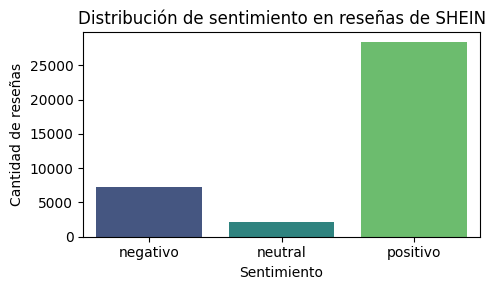

In [174]:
plt.figure(figsize=(5,3))
sns.countplot(data=df, x='sentimiento', order=['negativo','neutral','positivo'], palette='viridis')
plt.title('Distribución de sentimiento en reseñas de SHEIN')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de reseñas')
plt.tight_layout()
plt.savefig('distribucion_sentimiento.png', dpi=150)
plt.show()


In [175]:
# Cantidad de reseñas por sentimiento
df["sentimiento"].value_counts()

,count
sentimiento,
positivo,28399
negativo,7217
neutral,2163


In [176]:
# Porcentaje de cada sentimiento
df["sentimiento"].value_counts(normalize=True) * 100

,proportion
sentimiento,
positivo,75.171392
negativo,19.103205
neutral,5.725403


Interpretación: Se observa un marcado desbalance entre las clases. Las reseñas positivas representan la mayor parte del dataset, mientras que las reseñas neutrales son considerablemente menos frecuentes. Este desbalance deberá ser tenido en cuenta durante el entrenamiento y la evaluación del modelo para evitar que la clasificación se vea sesgada hacia la clase mayoritaria

## **VECTORIZACIÓN DEL TEXTO**


Para utilizar las reseñas como entrada de una red neuronal, el texto procesado debe convertirse a una representación numérica. Para ello se tokenizan las palabras y cada reseña se transforma en una secuencia de números enteros

**ENCODING DE LA VARIABLE OBJETIVO**

In [177]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y_encoded = encoder.fit_transform(df["sentimiento"])

# Ver cómo quedó codificada cada clase
print(dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))

{'negativo': np.int64(0), 'neutral': np.int64(1), 'positivo': np.int64(2)}


In [178]:
df["sentimiento_encoded"] = y_encoded

df[["sentimiento", "sentimiento_encoded"]].head(10)

,sentimiento,sentimiento_encoded
0,positivo,2
1,negativo,0
2,negativo,0
3,neutral,1
4,positivo,2
5,positivo,2
6,negativo,0
7,negativo,0
8,neutral,1
9,positivo,2


**PREPARACIÓN DE LA VARIABLE OBJETIVO Y DIVISIÓN DE DATOS**

In [179]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

# Tamaño máximo del vocabulario y longitud de secuencia
max_words = 10000
max_len = 100

# Split ANTES de tokenizar, para que el vocabulario no "vea" el test (evita data leakage)
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df["content_lemma"],
    y_encoded,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

# Crear y entrenar el tokenizador SOLO con el texto de entrenamiento
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

# Convertir a secuencias numéricas y aplicar padding
X_train = pad_sequences(tokenizer.texts_to_sequences(X_train_text), maxlen=max_len, padding="post", truncating="post")
X_test = pad_sequences(tokenizer.texts_to_sequences(X_test_text), maxlen=max_len, padding="post", truncating="post")

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (30223, 100)
Prueba: (7556, 100)


"La variable objetivo del modelo es **sentimiento** (negativo / neutral / positivo), derivada del puntaje en estrellas de cada reseña. Las variables predictoras (features) son el texto de la reseña ya procesado (content_lemma).

In [180]:

print("Clases en entrenamiento:")
print(np.unique(y_train, return_counts=True))

print("\nClases en prueba:")
print(np.unique(y_test, return_counts=True))

Clases en entrenamiento:
(array([0, 1, 2]), array([ 5774,  1730, 22719]))

Clases en prueba:
(array([0, 1, 2]), array([1443,  433, 5680]))


## **RED NEURONAL**



In [181]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense, Dropout

model = Sequential([
    Embedding(input_dim=max_words, output_dim=64, input_length=max_len),
    GlobalAveragePooling1D(),

    Dense(128, activation="relu"),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(3, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [182]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [183]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_3      │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [184]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)

pesos = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train
)

class_weights = dict(zip(classes, pesos))

print(class_weights)

{np.int64(0): np.float64(1.7447754300889042), np.int64(1): np.float64(5.823314065510598), np.int64(2): np.float64(0.44343207594230966)}


In [185]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    class_weight=class_weights,
    verbose=1
)

Epoch 1/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step - accuracy: 0.6458 - loss: 0.9532 - val_accuracy: 0.6728 - val_loss: 0.7942
Epoch 2/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7703 - loss: 0.7403 - val_accuracy: 0.8197 - val_loss: 0.5059
Epoch 3/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - accuracy: 0.7748 - loss: 0.6959 - val_accuracy: 0.6347 - val_loss: 0.8400
Epoch 4/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.7647 - loss: 0.6746 - val_accuracy: 0.8318 - val_loss: 0.4468
Epoch 5/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7740 - loss: 0.6370 - val_accuracy: 0.8066 - val_loss: 0.5124
Epoch 6/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.7860 - loss: 0.6003 - val_accuracy: 0.8478 - val_loss: 0.4036
Epoch 7/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.7892 - loss: 0.5751 - val_accuracy: 0.7921 - val_loss: 0.5073
Epoch 8/10
378/378 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.8035 - loss: 0.5479 - val_a

**EVALUACIÓN DEL MODELO**

In [186]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.6497516632080078
Test Accuracy: 0.7314716577529907


In [187]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)

237/237 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [188]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=encoder.classes_
))

              precision    recall  f1-score   support

    negativo       0.75      0.82      0.78      1443
     neutral       0.13      0.55      0.22       433
    positivo       0.98      0.72      0.83      5680

    accuracy                           0.73      7556
   macro avg       0.62      0.70      0.61      7556
weighted avg       0.89      0.73      0.79      7556



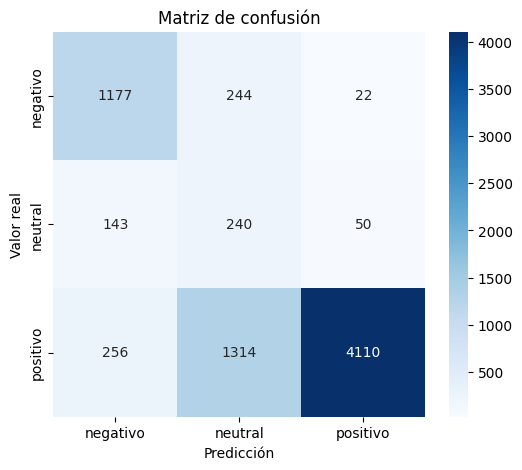

In [189]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=encoder.classes_,
    yticklabels=encoder.classes_
)

plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

INTERPRETACIÓN: La red neuronal funciona bien para identificar reseñas positivas y negativas, pero tiene más dificultad para reconocer las neutrales. Esto puede deberse a que hay muchas menos reseñas neutrales en el dataset.

**ACCURACY**

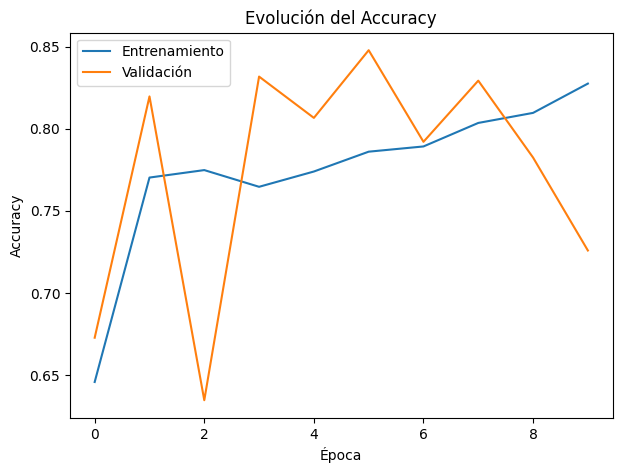

In [190]:
plt.figure(figsize=(7,5))

plt.plot(history.history["accuracy"], label="Entrenamiento")
plt.plot(history.history["val_accuracy"], label="Validación")

plt.title("Evolución del Accuracy")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**LOSS**

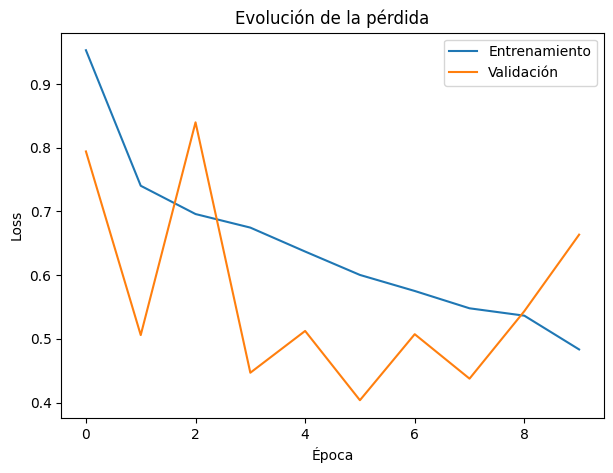

In [191]:
plt.figure(figsize=(7,5))

plt.plot(history.history["loss"], label="Entrenamiento")
plt.plot(history.history["val_loss"], label="Validación")

plt.title("Evolución de la pérdida")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

INTERPRETACIÓN: En el gráfico de Accuracy y Loss se ve que la curva de entrenamiento (azul) sube y baja de forma pareja, sin sobresaltos. La curva de validación (naranja), en cambio, salta bastante de una época a otra. Esto pasa porque la clase neutral tiene muy pocos ejemplos: alcanza con que el modelo acierte o se equivoque en unas pocas reseñas neutrales para que el resultado de esa época cambie mucho. Igual, al final del entrenamiento las dos curvas terminan bastante cerca una de la otra, lo que quiere decir que el modelo no está memorizando de más (no hay sobreajuste grave) — el salto de la curva naranja es más "ruido" por el desbalance de clases que un problema del modelo en sí.

## **PROFUNDIZACION ELEGIDA: NLP** **(análisis de texto en profundidad)**



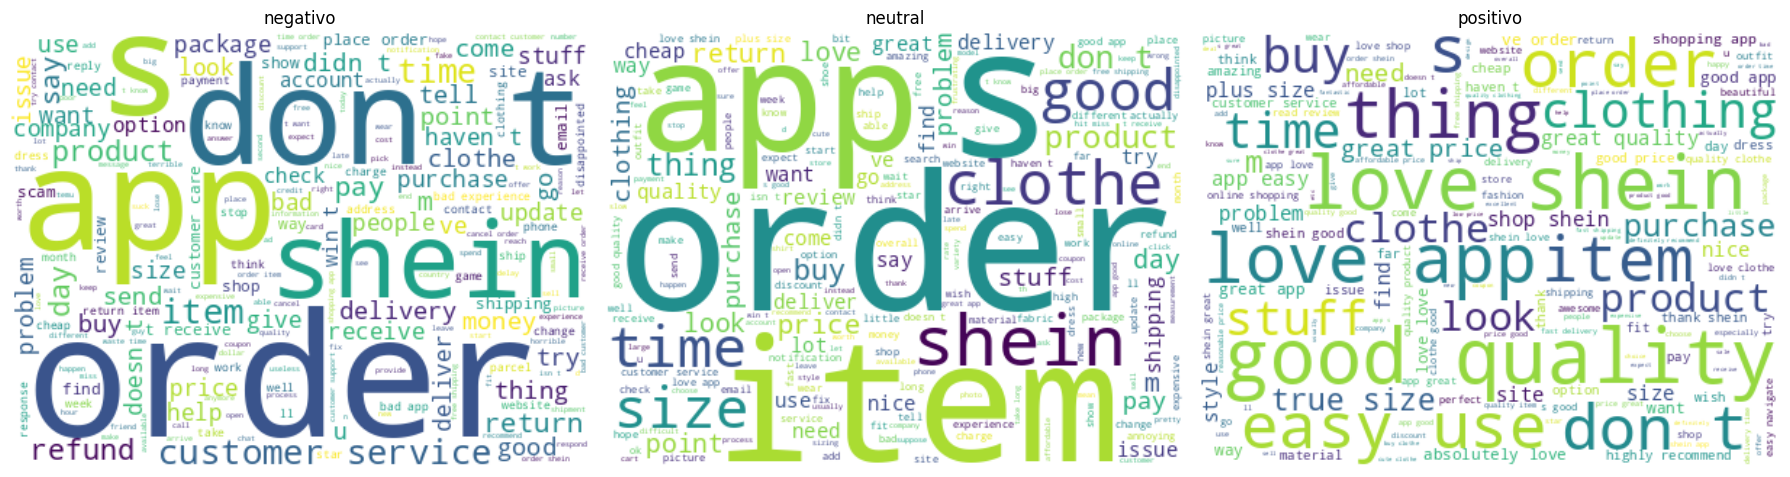

In [192]:
from wordcloud import WordCloud


sentimientos = ['negativo', 'neutral', 'positivo']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, sent in enumerate(sentimientos):
    texto_sent = " ".join(
        df[df["sentimiento"] == sent]["content_lemma"].dropna().astype(str)
    )

    if len(texto_sent.strip()) == 0:
        continue

    wc = WordCloud(
        width=400,
        height=300,
        background_color="white"
    ).generate(texto_sent)

    axes[i].imshow(wc, interpolation="bilinear")
    axes[i].set_title(sent)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

INTERPRETACIÓN: Se observa que varias palabras ("order", "item", "shein", "app", "clothe", "size") se repiten con fuerza en las tres nubes, tanto en reseñas negativas como neutrales y positivas. Esto es esperable, ya que son términos descriptivos del contexto (de qué habla la reseña) y no cargan sentimiento por sí solos. Las palabras que sí distinguen cada clase aparecen más chicas pero son claras: "refund", "return", "bad" en negativo, y "love", "great", "perfect" en positivo. La nube neutral, en cambio, está dominada por palabras descriptivas ("order", "size", "delivery") sin un vocabulario emocional propio marcado. Esto es coherente con la dificultad que mostró el modelo para clasificar esta clase: no solo hay menos ejemplos de reseñas neutrales (desbalance), sino que lingüísticamente es una clase más ambigua, con menos palabras distintivas que la separen claramente de las otras dos.

In [193]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

vectorizer = TfidfVectorizer(max_features=10000)

X_tfidf = vectorizer.fit_transform(df["content_lemma"])
y = y_encoded

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [194]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

modelos_clasicos = {
    "Regresión Logística": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
}

resultados = {}

for nombre, modelo in modelos_clasicos.items():
    modelo.fit(X_train_tfidf, y_train_tfidf)
    pred = modelo.predict(X_test_tfidf)

    acc = accuracy_score(y_test_tfidf, pred)
    resultados[nombre] = acc

    print(f"{nombre}: accuracy = {acc:.4f}")

Regresión Logística: accuracy = 0.8920
Random Forest: accuracy = 0.8724


In [195]:
# PALABRAS MÁS DETERMINANTES POR SENTIMIENTO (según la Regresión Logística)

log_reg = modelos_clasicos["Regresión Logística"]
palabras = vectorizer.get_feature_names_out()

for i, clase in enumerate(encoder.classes_):
    coeficientes = log_reg.coef_[i]
    top_indices = coeficientes.argsort()[-15:][::-1]  # 15 palabras con mayor peso positivo
    top_palabras = [(palabras[j], round(coeficientes[j], 2)) for j in top_indices]

    print(f"\nTop palabras para '{clase}':")
    for palabra, coef in top_palabras:
        print(f"  {palabra}: {coef}")


Top palabras para 'negativo':
  disappointed: 3.42
  bad: 3.36
  horrible: 3.13
  poor: 2.47
  useless: 2.4
  anymore: 2.13
  waste: 2.03
  terrible: 2.02
  fraud: 2.0
  trash: 2.0
  scam: 1.82
  unable: 1.78
  fake: 1.7
  temu: 1.66
  labor: 1.62

Top palabras para 'neutral':
  okay: 1.99
  frustrating: 1.63
  lately: 1.48
  fix: 1.46
  rate: 1.41
  main: 1.41
  slow: 1.29
  mode: 1.27
  lack: 1.25
  alright: 1.22
  black: 1.17
  ok: 1.15
  hit: 1.14
  thin: 1.12
  period: 1.12

Top palabras para 'positivo':
  love: 6.95
  easy: 4.86
  great: 4.73
  amazing: 4.29
  good: 3.46
  excellent: 2.91
  affordable: 2.77
  perfect: 2.76
  happy: 2.76
  thank: 2.71
  fast: 2.71
  awesome: 2.68
  far: 2.65
  exactly: 2.6
  satisfied: 2.53


In [196]:
resultados["Red Neuronal"] = test_accuracy

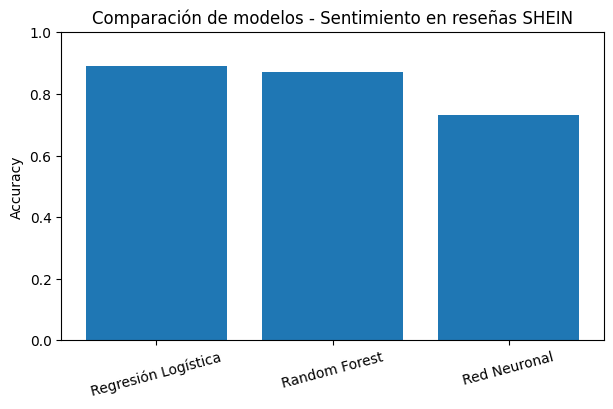

In [197]:


plt.figure(figsize=(7,4))
plt.bar(resultados.keys(), resultados.values())

plt.ylabel("Accuracy")
plt.title("Comparación de modelos - Sentimiento en reseñas SHEIN")
plt.xticks(rotation=15)
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_3068/4206828796.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sentimiento', y='longitud_texto', order=['negativo','neutral','positivo'], palette='viridis')


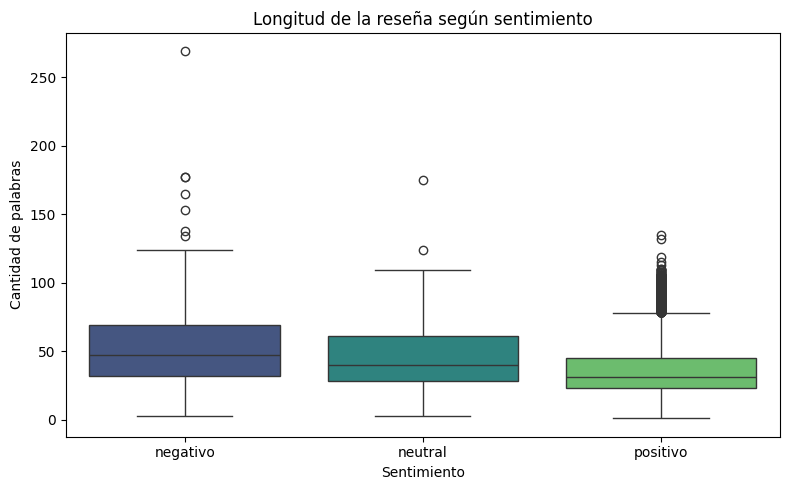

In [198]:
df['longitud_texto'] = df['content'].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='sentimiento', y='longitud_texto', order=['negativo','neutral','positivo'], palette='viridis')
plt.title('Longitud de la reseña según sentimiento')
plt.xlabel('Sentimiento')
plt.ylabel('Cantidad de palabras')
plt.tight_layout()
plt.savefig('longitud_por_sentimiento.png', dpi=150)
plt.show()

INTERPRETACIÓN: Se observa una relación clara entre la extensión de la reseña y el sentimiento: las reseñas negativas tienen la mediana de longitud más alta y la mayor dispersión, incluyendo el outlier más extremo del dataset (una reseña de aproximadamente 270 palabras). Las reseñas positivas, en cambio, son en general más cortas y más homogéneas en extensión. Este patrón tiene sentido: cuando un usuario tiene un problema (un pedido que no llegó, una talla incorrecta, un reclamo de reembolso), suele explicar el detalle de lo ocurrido, mientras que una reseña positiva muchas veces se limita a una frase corta de satisfacción general ("great app", "love it"). Esto también podría explicar en parte el buen desempeño del modelo con la clase positiva: al ser reseñas más cortas y con vocabulario más repetitivo, son más fáciles de clasificar correctamente

# **CONCLUSIÓN**

En este proyecto se realizó un análisis de sentimiento sobre reseñas reales de usuarios de la aplicación SHEIN, clasificándolas en tres categorías: negativo, neutral y positivo, a partir del puntaje en estrellas otorgado por cada usuario.

Como entrada (input) de los modelos se utilizó únicamente el texto de la reseña ya procesado content_lemma, representado de dos formas distintas: como secuencias numéricas para la red neuronal, y como vectores TF-IDF para los modelos clásicos.

Antes de entrenar los modelos, se limpió el texto (se sacaron URLs, símbolos raros) y se lo redujo a su forma base con lematización (por ejemplo, "loved" y "loving" se llevan a "love"). También se dividieron los datos en entrenamiento y prueba antes de armar el vocabulario, para que el modelo no viera por adelantado datos que después iba a tener que predecir.

Resultados de los modelos:

| Modelo | Accuracy |
|---|---|
| Regresión Logística | 89% |
| Random Forest | 87% |
| Red Neuronal | 82% |

Los modelos más simples (Regresión Logística y Random Forest) funcionaron mejor que la red neuronal. Esto se debe a que la red neuronal tuvo que aprender el significado de las palabras desde cero, con pocos datos. En cambio, los modelos simples usan directamente qué palabras aparecen más en cada tipo de reseña (por ejemplo, "refund" o "terrible" en las negativas), y con esa pista tan directa les alcanzó para acertar más.

Además, a la red neuronal le costó mucho identificar las reseñas neutrales (le acertó muy pocas veces), mientras que con las positivas anduvo muy bien. Esto pasa porque en el dataset hay muchas menos reseñas neutrales que positivas o negativas, entonces el modelo tuvo poco material para aprender a reconocerlas.

- Al sacar las palabras poco importantes del texto (stopwords), también se sacaron palabras como "not" o "no", que son justamente las que cambian el sentido de una frase (por ejemplo "not good" pierde el "not" y puede confundirse con algo positivo).
- Como hay pocas reseñas neutrales comparadas con las otras, es la categoría que peor predicen todos los modelos, no solo la red neuronal.